<a href="https://colab.research.google.com/github/itskevalchaudhari/AIML-Practicals/blob/main/Practical-05/Practical_05_KNN_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 05: K-Nearest Neighbors (KNN) Classification

## Aim

To implement the K-Nearest Neighbors (KNN) classification algorithm on a dataset and evaluate its performance using suitable classification metrics.

## Theory

K-Nearest Neighbors (KNN) is a supervised machine learning algorithm used for classification and regression problems. For classification, KNN assigns a class to a new data point based on the classes of its nearest neighboring data points.

KNN is called a lazy learning algorithm because it does not explicitly build a model during the training phase. Instead, it stores the training data and performs calculations when a prediction is required.

### Working of KNN

The main steps involved in KNN classification are:

1. Select the value of K, which represents the number of nearest neighbors.
2. Calculate the distance between the new data point and all training data points.
3. Select the K data points having the smallest distances.
4. Determine the class that occurs most frequently among these K neighbors.
5. Assign that class to the new data point.

### Euclidean Distance

The commonly used distance measure in KNN is Euclidean distance.

For two data points:

X = (x₁, x₂, ..., xₙ)

Y = (y₁, y₂, ..., yₙ)

the Euclidean distance is:

d(X,Y) = √[Σ(xᵢ - yᵢ)²]

For two-dimensional data:

d = √[(x₁-y₁)² + (x₂-y₂)²]

### K Value

The value of K determines how many neighboring observations participate in the classification.

- Small K values can make the model sensitive to noise.
- Large K values can make the model less sensitive to individual observations.
- An appropriate K value generally provides better classification performance.

### Feature Scaling

KNN is distance-based, so features with larger numerical ranges can dominate the distance calculation. Therefore, feature scaling is commonly applied before training the KNN classifier.

In this practical, StandardScaler will be used to standardize the features before applying KNN.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset

iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

print("\nFirst five records:")
display(df.head())

Dataset loaded successfully!
Dataset Shape: (150, 5)

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# Display dataset information

print("Dataset Information:\n")
df.info()

print("\nStatistical Summary:")
display(df.describe())

print("\nTarget Class Distribution:")
print(df["target"].value_counts().sort_index())

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Target Class Distribution:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [4]:
# Separate input features and target variable

X = df.drop("target", axis=1)
y = df["target"]

print("Features (X) Shape:", X.shape)
print("Target (y) Shape:", y.shape)

print("\nFeature Names:")
print(list(X.columns))

print("\nTarget Classes:")
print(sorted(y.unique()))

Features (X) Shape: (150, 4)
Target (y) Shape: (150,)

Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target Classes:
[np.int64(0), np.int64(1), np.int64(2)]


In [5]:
# Import train-test split
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (120, 4)
Testing set size: (30, 4)


In [6]:
# Import StandardScaler
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (120, 4)
Scaled testing data shape: (30, 4)


In [7]:
# Import KNN classifier
from sklearn.neighbors import KNeighborsClassifier

# Create the KNN model with K = 5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn.fit(X_train_scaled, y_train)

print("KNN model trained successfully!")
print("Number of Neighbors (K):", knn.n_neighbors)

KNN model trained successfully!
Number of Neighbors (K): 5


In [8]:
# Predict the classes for the test data

y_pred = knn.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nActual classes:")
print(y_test.to_numpy())

print("\nPredicted classes:")
print(y_pred)

Predictions generated successfully!

Actual classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]

Predicted classes:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]


In [9]:
# Import evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("KNN Model Evaluation Metrics")
print("----------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

KNN Model Evaluation Metrics
----------------------------
Accuracy  : 0.9333
Precision : 0.9444
Recall    : 0.9333
F1-Score  : 0.9327


Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]


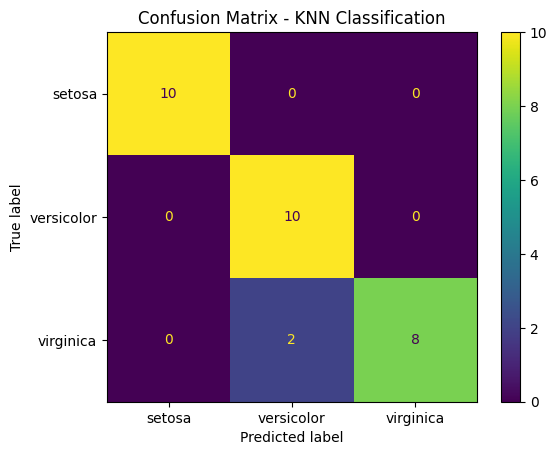

In [10]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot()
plt.title("Confusion Matrix - KNN Classification")
plt.show()

In [11]:
# Generate classification report

from sklearn.metrics import classification_report

print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [12]:
# Compare KNN accuracy for different values of K

k_values = range(1, 16)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    predictions = model.predict(X_test_scaled)
    score = accuracy_score(y_test, predictions)

    accuracies.append(score)

# Find the best K
best_k = k_values[np.argmax(accuracies)]
best_accuracy = max(accuracies)

print("Best K:", best_k)
print(f"Best Accuracy: {best_accuracy:.4f}")

Best K: 1
Best Accuracy: 0.9667


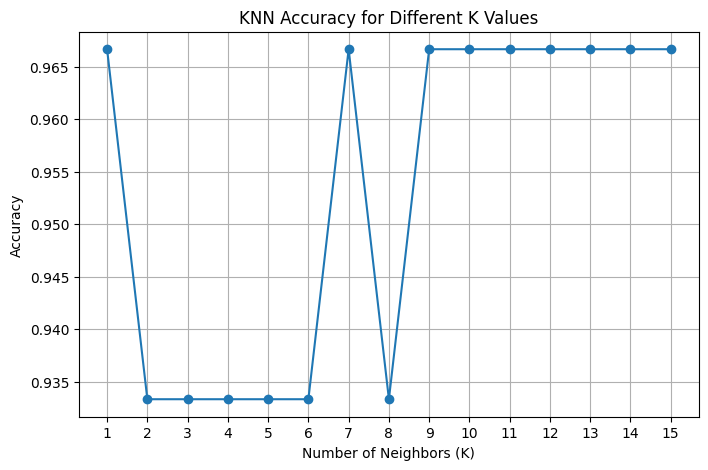

In [13]:
# Plot K value versus accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    list(k_values),
    accuracies,
    marker='o'
)

plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN Accuracy for Different K Values')
plt.xticks(list(k_values))
plt.grid(True)

plt.show()

## Result and Conclusion

The K-Nearest Neighbors (KNN) classification algorithm was successfully implemented on the Iris dataset. The dataset was divided into training and testing sets, and feature scaling was performed using StandardScaler.

The KNN classifier was evaluated for different values of K ranging from 1 to 15. The accuracy varied with the choice of K, demonstrating the importance of selecting an appropriate number of neighbors.

The highest test accuracy obtained was **96.67%**, achieved for K = 1, 7, and values from 9 to 15. The model performed well in classifying the three Iris species: Setosa, Versicolor, and Virginica.

The results demonstrate that KNN is an effective and simple supervised classification algorithm. Proper feature scaling and selection of a suitable K value can significantly influence its performance.

Therefore, KNN successfully classified the Iris dataset with high accuracy and demonstrated its usefulness for classification problems.